# EXPLORATORY DATA ANALYSIS

We start this project by getting familiar with the dataset we are going to use. We should be able to know the following:
1) What are our variables?
2) How many observations? are there NAs?
3) Deal with missing values if required
4) Study correlations and the distributions of our numerical variables
5) Having a good idea of what variables could be important for the model, potential interactions and transformations.

## Data diagnosis

In [19]:
# Importing necessary libraries
import pandas as pd

In [20]:
# Loading the dataset
df = pd.read_csv('../data/raw/heart_failure_clinical_records_dataset.csv')
# Look for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)
# Displaying the first few rows of the dataset
df.head()

Missing values in each column:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [21]:
# Looking at the summary statistics of the dataset
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### Skweness, outliers and distributions

In [27]:
import sys
sys.path.append("../src")
from data.data_utils import plot_boxplot_hist_by_skew, outlier_skew_table, correlation_heatmap, target_distribution, box_histograms_all

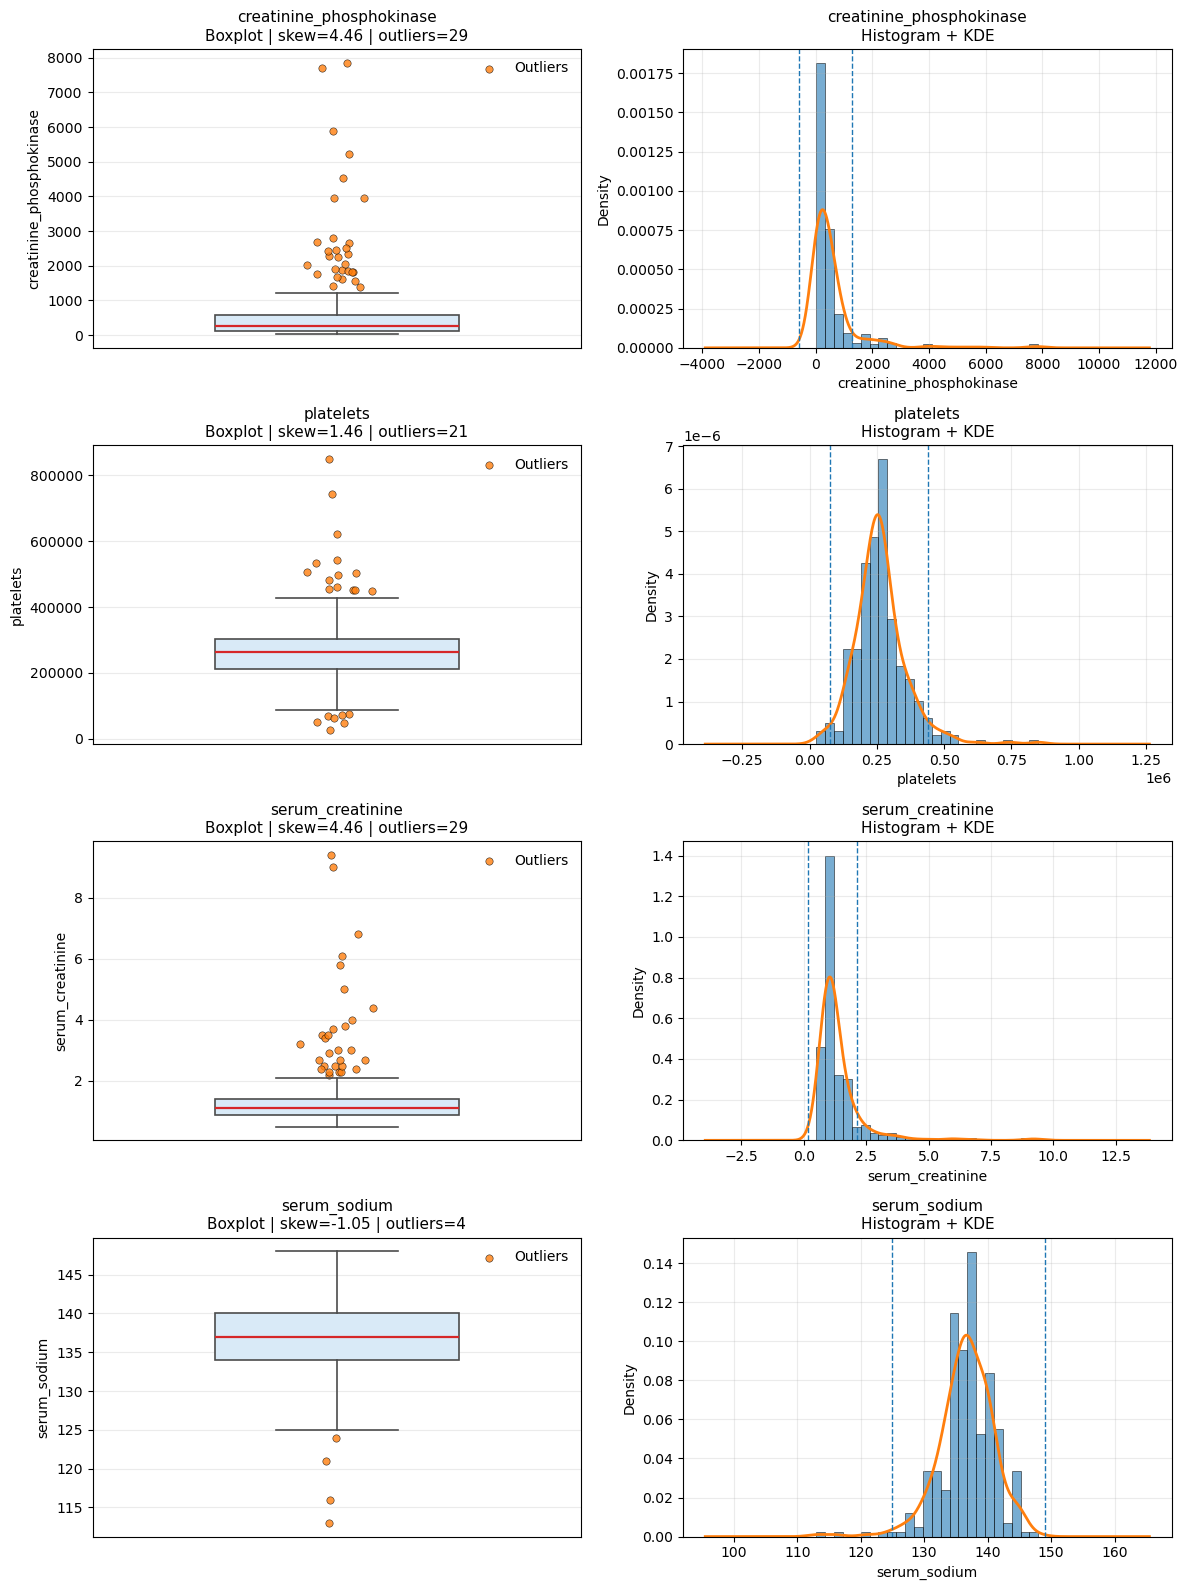

,variable,skewness,abs_skew,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers,skew_flag,outlier_flag,problematic
0,creatinine_phosphokinase,4.463,4.463,116.5,582.0,465.5,-581.75,1280.25,29,0.097,True,True,True
1,serum_creatinine,4.456,4.456,0.9,1.4,0.5,0.15,2.15,29,0.097,True,True,True
2,platelets,1.462,1.462,212500.0,303500.0,91000.0,76000.00,440000.00,21,0.070,True,True,True
3,serum_sodium,-1.048,1.048,134.0,140.0,6.0,125.00,149.00,4,0.013,True,False,True


In [26]:
plot_boxplot_hist_by_skew(
    df,
    exclude=["DEATH_EVENT"],
    skew_threshold=1.0,
    bins=25
)

table = outlier_skew_table(
    df,
    exclude=["DEATH_EVENT"]
)

#print(table)

table[table["problematic"]]

Several continuous variables (particularly biochemical markers) exhibit skewed distributions and extreme values, which may introduce influential observations.

### Relation with the target

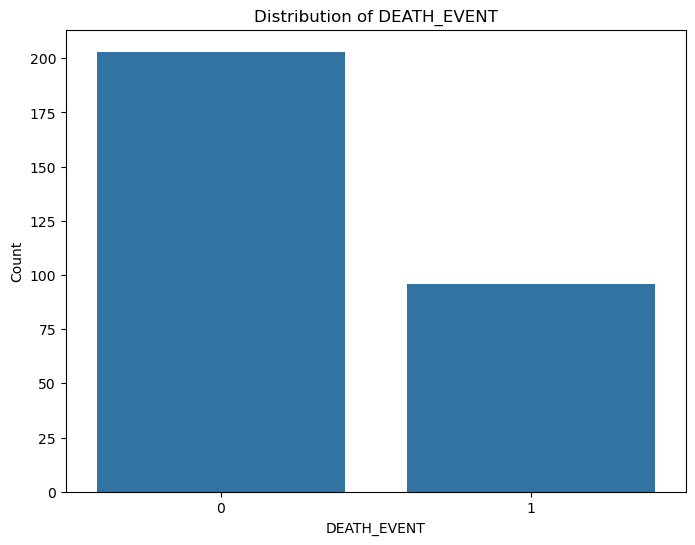

In [24]:
# Distribution of target variable
target_distribution(df, target_col='DEATH_EVENT')

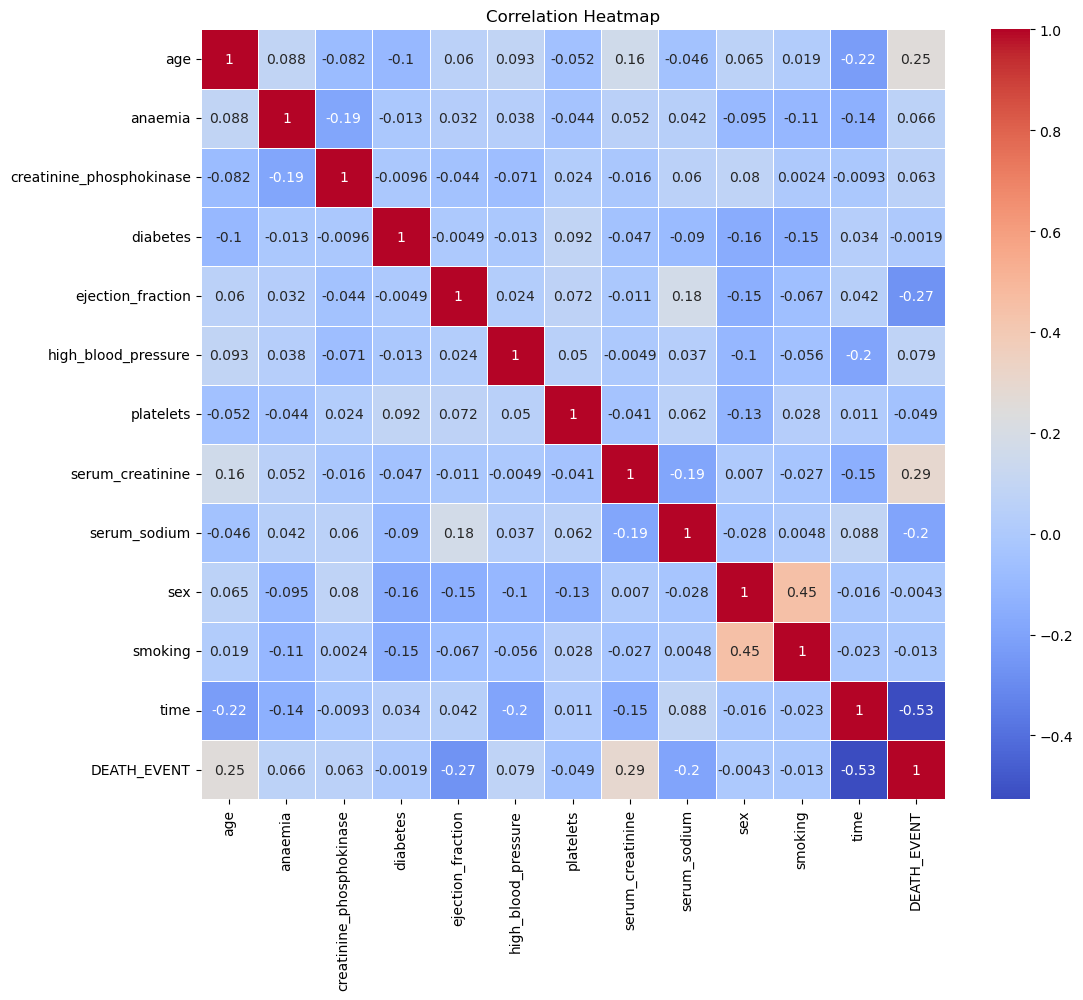

In [25]:
# Correlation heatmap
correlation_heatmap(df)

Binary variables are included for completeness, although correlation values for such variables should be interpreted with caution.

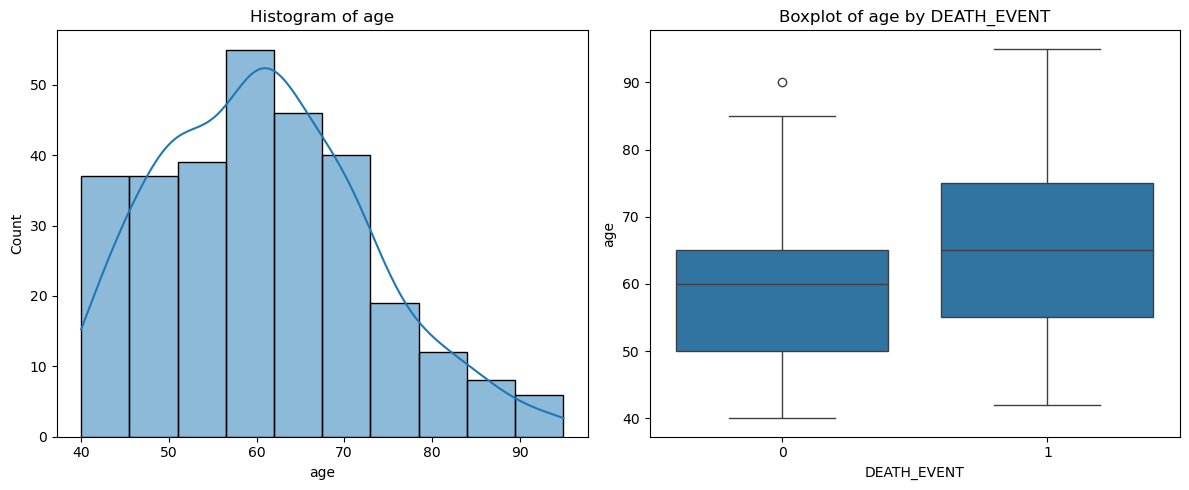

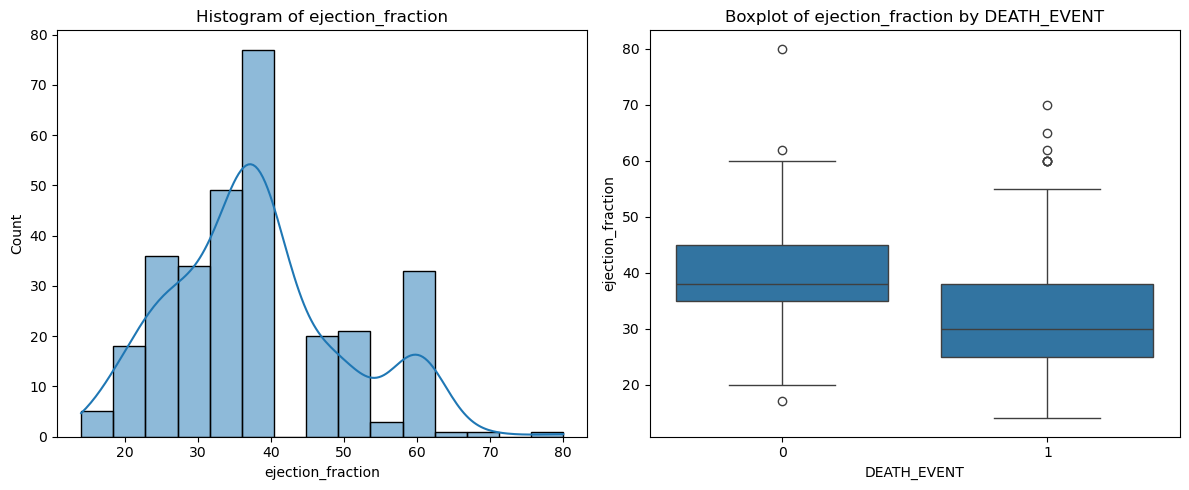

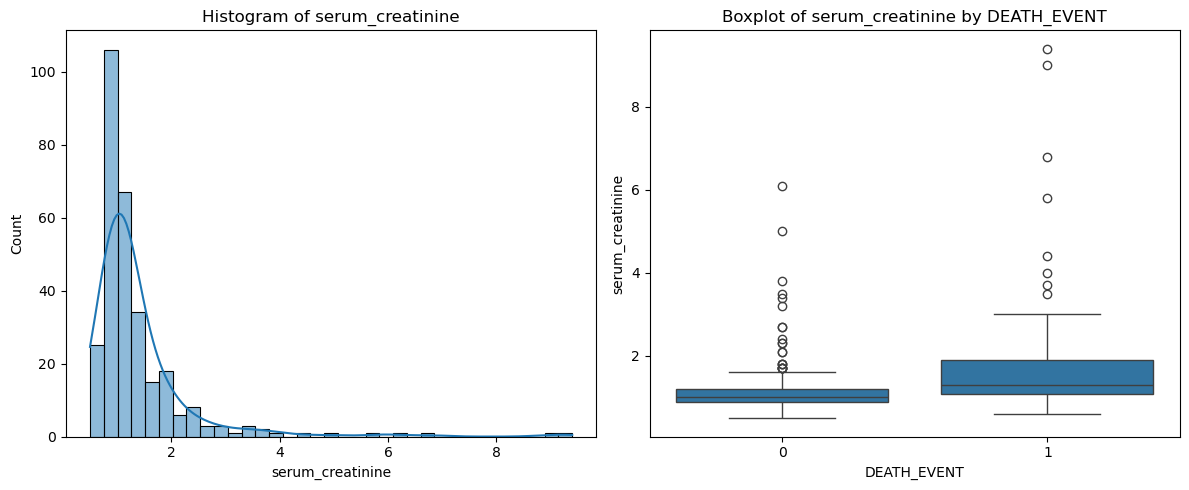

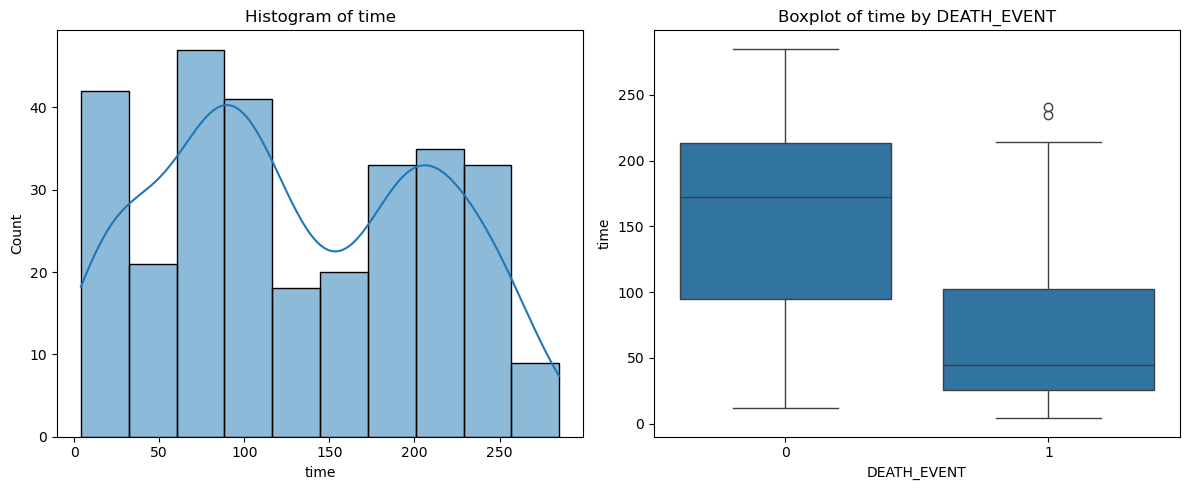

In [28]:
box_histograms_all(df, 'DEATH_EVENT', threshold=0.2)

These are the variables that show the strongest linear association with the target, suggesting potential predictive relevance